In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
column_names = [
    'status_konta', 'czas_trwania_msc', 'historia_kredytowa', 'cel_kredytu',
    'kwota_kredytu', 'stan_oszczednosci', 'zatrudnienie_od',
    'raty_proc_dochodu', 'stan_cywilny_plec', 'inni_dluznicy',
    'lata_w_miejscu_zamieszkania', 'majatek', 'wiek',
    'inne_raty', 'mieszkanie', 'liczba_kredytow_w_banku',
    'zawod', 'liczba_osob_na_utrzymaniu', 'telefon', 'pracownik_zagraniczny',
    'target'
]

df = pd.read_csv('../data/raw/german_credit/german.data', sep=' ', header=None, names=column_names)
df['target'] = df['target'].map({1:0, 2:1})

df.head()

,status_konta,czas_trwania_msc,historia_kredytowa,cel_kredytu,kwota_kredytu,stan_oszczednosci,zatrudnienie_od,raty_proc_dochodu,stan_cywilny_plec,inni_dluznicy,...,majatek,wiek,inne_raty,mieszkanie,liczba_kredytow_w_banku,zawod,liczba_osob_na_utrzymaniu,telefon,pracownik_zagraniczny,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [3]:
categorical_cols = df.select_dtypes(include='str').columns.tolist()

print("Kolumny do zakodowania:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

Kolumny do zakodowania: ['status_konta', 'historia_kredytowa', 'cel_kredytu', 'stan_oszczednosci', 'zatrudnienie_od', 'stan_cywilny_plec', 'inni_dluznicy', 'majatek', 'inne_raty', 'mieszkanie', 'zawod', 'telefon', 'pracownik_zagraniczny']


,czas_trwania_msc,kwota_kredytu,raty_proc_dochodu,lata_w_miejscu_zamieszkania,wiek,liczba_kredytow_w_banku,liczba_osob_na_utrzymaniu,target,status_konta_A12,status_konta_A13,...,majatek_A124,inne_raty_A142,inne_raty_A143,mieszkanie_A152,mieszkanie_A153,zawod_A172,zawod_A173,zawod_A174,telefon_A192,pracownik_zagraniczny_A202
0,6,1169,4,4,67,2,1,0,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,1,True,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,0,False,False,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,0,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,1,False,False,...,True,False,True,False,True,False,True,False,False,False


In [4]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 48)
y shape: (1000,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 48)
X_test shape: (200, 48)
y_train shape: (800,)
y_test shape: (200,)


In [6]:
numeric_cols = [
    'czas_trwania_msc', 'kwota_kredytu', 'raty_proc_dochodu',
    'lata_w_miejscu_zamieszkania', 'wiek', 'liczba_kredytow_w_banku',
    'liczba_osob_na_utrzymaniu'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled[numeric_cols].describe()

,czas_trwania_msc,kwota_kredytu,raty_proc_dochodu,lata_w_miejscu_zamieszkania,wiek,liczba_kredytow_w_banku,liczba_osob_na_utrzymaniu
count,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02
mean,6.217249e-17,3.608225e-17,-1.132427e-16,-7.993606e-17,3.153033e-16,6.661338e-17,2.708944e-16
std,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00
min,-1.419991e+00,-1.090467e+00,-1.727486e+00,-1.647646e+00,-1.478814e+00,-7.187455e-01,-4.364358e-01
25%,-7.425950e-01,-6.873790e-01,-8.376025e-01,-7.472930e-01,-7.540716e-01,-7.187455e-01,-4.364358e-01
50%,-2.345483e-01,-3.265838e-01,5.228063e-02,1.530600e-01,-2.105150e-01,-7.187455e-01,-4.364358e-01
75%,2.734985e-01,2.782348e-01,9.421638e-01,1.053413e+00,5.142273e-01,1.045047e+00,-4.364358e-01
max,3.321779e+00,4.773953e+00,9.421638e-01,1.053413e+00,3.594382e+00,4.572632e+00,2.291288e+00


## Podsumowanie preprocessingu
- Zmienne kategoryczne zakodowane przez One-Hot Encoding (drop_first=True) -> 48 kolumn cech
- Podział danych: 80% trening (800 klientów) / 20% test (200 klientów), stratyfikowany wg targetu
- Zmienne numeryczne wystandaryzowane (StandardScaler) - fit tylko na zbiorze treningowym, żeby uniknąć data leakage
- Dane gotowe do modelowania

In [7]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', random_state=42)

log_reg.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [8]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred[:10]

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC_AUC: {roc_auc:.3f}")

Accuracy: 0.740
Precision: 0.547
Recall: 0.783
F1-score: 0.644
ROC_AUC: 0.807


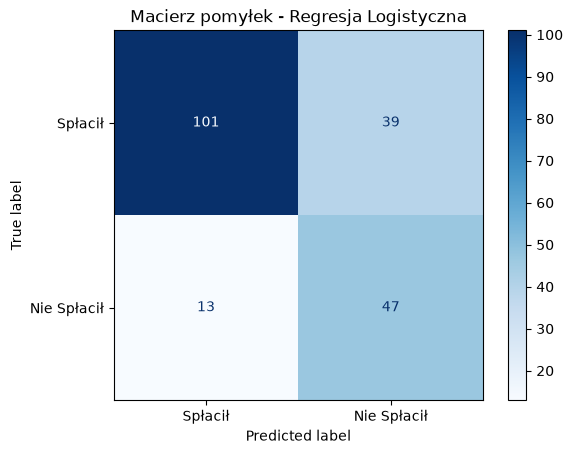

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Spłacił', 'Nie Spłacił'])
disp.plot(cmap='Blues')
plt.title('Macierz pomyłek - Regresja Logistyczna')
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [12]:
y_pred_rf = rf.predict(X_test_scaled)
y_pred_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Accuracy: {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-score: {f1_rf:.3f}")
print(f"ROC-AUC: {roc_auc_rf:.3f}")

Accuracy: 0.720
Precision: 0.530
Recall: 0.583
F1-score: 0.556
ROC-AUC: 0.774


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid ={
    'n_estimators': [100,200,300],
    'max_depth': [5,10,15,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [14]:
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=1
)

grid_search.fit(X_train_scaled, y_train)

print("Najlepsze hiperparametry:",grid_search.best_params_)
print("Najlepszy wynik ROC-AUC(walidacja krzyżowa):", grid_search.best_score_)

Najlepsze hiperparametry: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Najlepszy wynik ROC-AUC(walidacja krzyżowa): 0.7895833333333334


In [15]:
best_rf = grid_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test_scaled)
y_pred_proba_rf_tuned = best_rf.predict_proba(X_test_scaled)[:, 1]

accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned =recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)
roc_auc_rf_tuned = roc_auc_score(y_test, y_pred_proba_rf_tuned)

print(f"Accuracy: {accuracy_rf_tuned:.3f}")
print(f"Precision: {precision_rf_tuned:.3f}")
print(f"Recall: {recall_rf_tuned:.3f}")
print(f"F1-score: {f1_rf_tuned:.3f}")
print(f"ROC-AUC: {roc_auc_rf_tuned:.3f}")

Accuracy: 0.720
Precision: 0.524
Recall: 0.717
F1-score: 0.606
ROC-AUC: 0.801


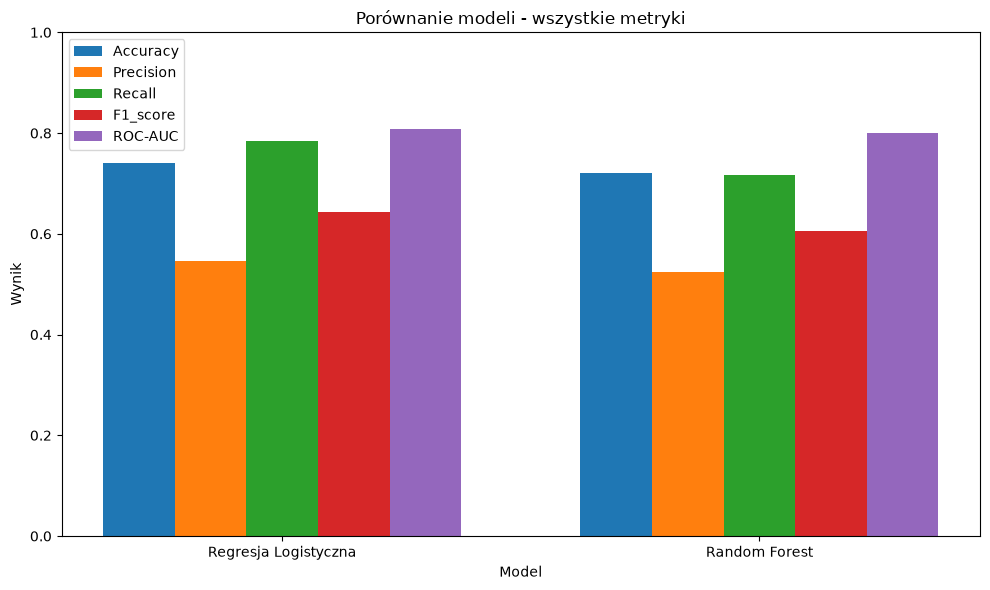

In [16]:
models = ['Regresja Logistyczna','Random Forest']
metrics_comparision = {
    'Accuracy': [accuracy, accuracy_rf_tuned],
    'Precision': [precision, precision_rf_tuned],
    'Recall': [recall, recall_rf_tuned],
    'F1_score': [f1, f1_rf_tuned],
    'ROC-AUC': [roc_auc, roc_auc_rf_tuned]
}

x = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(10,6))

for i, (metric_name, values) in enumerate(metrics_comparision.items()):
    ax.bar(x + i * width, values, width, label=metric_name)

ax.set_xlabel('Model')
ax.set_ylabel('Wynik')
ax.set_title('Porównanie modeli - wszystkie metryki')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Podsumowanie modelowania

Przetestowano dwa modele klasyfikacji binarnej do przewidywania ryzyka niespłacenia kredytu:

1. **Regresja Logistyczna** (baseline) - class_weight='balanced'
2. **Random Forest** - dostrojony przez GridSearchCV (5-fold cross-validation, scoring=roc_auc)
   - Najlepsze hiperparametry: max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=300

### Wyniki na zbiorze testowym

| Metryka | Regresja Logistyczna | Random Forest (tuned) |
|---|---|---|
| Accuracy | 0.740 | 0.720 |
| Precision | 0.547 | 0.524 |
| Recall | 0.783 | 0.717 |
| F1-score | 0.644 | 0.606 |
| ROC-AUC | 0.807 | 0.801 |

### Wnioski
- Regresja logistyczna nieznacznie przewyższa Random Forest, mimo tuningu hiperparametrów
- Prawdopodobne przyczyny: mały rozmiar datasetu (800 próbek treningowych) oraz w większości liniowy 
  charakter zależności między cechami a targetem
- Tuning znacząco poprawił Random Forest (ROC-AUC: 0.774 -> 0.801), ale nie przewyższył baseline'u
- Wysoki recall (0.783 dla regresji logistycznej) jest pożądany w tym kontekście biznesowym - 
  model dobrze wykrywa klientów obarczonych ryzykiem niespłacenia kredytu
- Regresja logistyczna, jako model prostszy i w pełni interpretowalny, może być preferowana 
  w praktyce bankowej (łatwiejsze wyjaśnienie decyzji kredytowych)

### Możliwe rozszerzenia
- XGBoost / LightGBM (prawdopodobnie porównywalny wynik na tym datasecie, większa przewaga 
  spodziewana na większych, bardziej złożonych zbiorach danych)
- Rozszerzenie o dataset Home Credit Default Risk (większy, wielotabelowy, więcej nieliniowości)